[INFO] Loading data from: /Users/sadigulcelik/Documents/CompSci/ScalingLLM-2025-Fall/Project/draft_repo_clean/output/llama3_large
[INFO] Loaded 5 samples.

Table 1: Predictive Performance
                Metric  AUROC  AP (PR-AUC)  Point-Biserial (r_pb)      P-Value
  Semantic (Consensus)    1.0       1.0000                -1.0000 3.971900e-24
      Entropic (Token)    0.5       0.3333                 0.1244 8.420600e-01
     SAUP (Aggregated)    0.5       0.3333                -0.0802 8.979500e-01
Mechanistic (Internal)    0.5       0.3333                 0.0729 9.072800e-01
       Logit Gap (Inv)    0.0       0.2000                 0.8788 4.973800e-02

Table 2: Synergy Analysis
                                  Metric Pair  Pearson Correlation Interpretation
         Entropic (Token) / SAUP (Aggregated)               0.9770      Redundant
   SAUP (Aggregated) / Mechanistic (Internal)               0.9082      Redundant
       Logit Gap (Inv) / Semantic (Consensus)               0.878

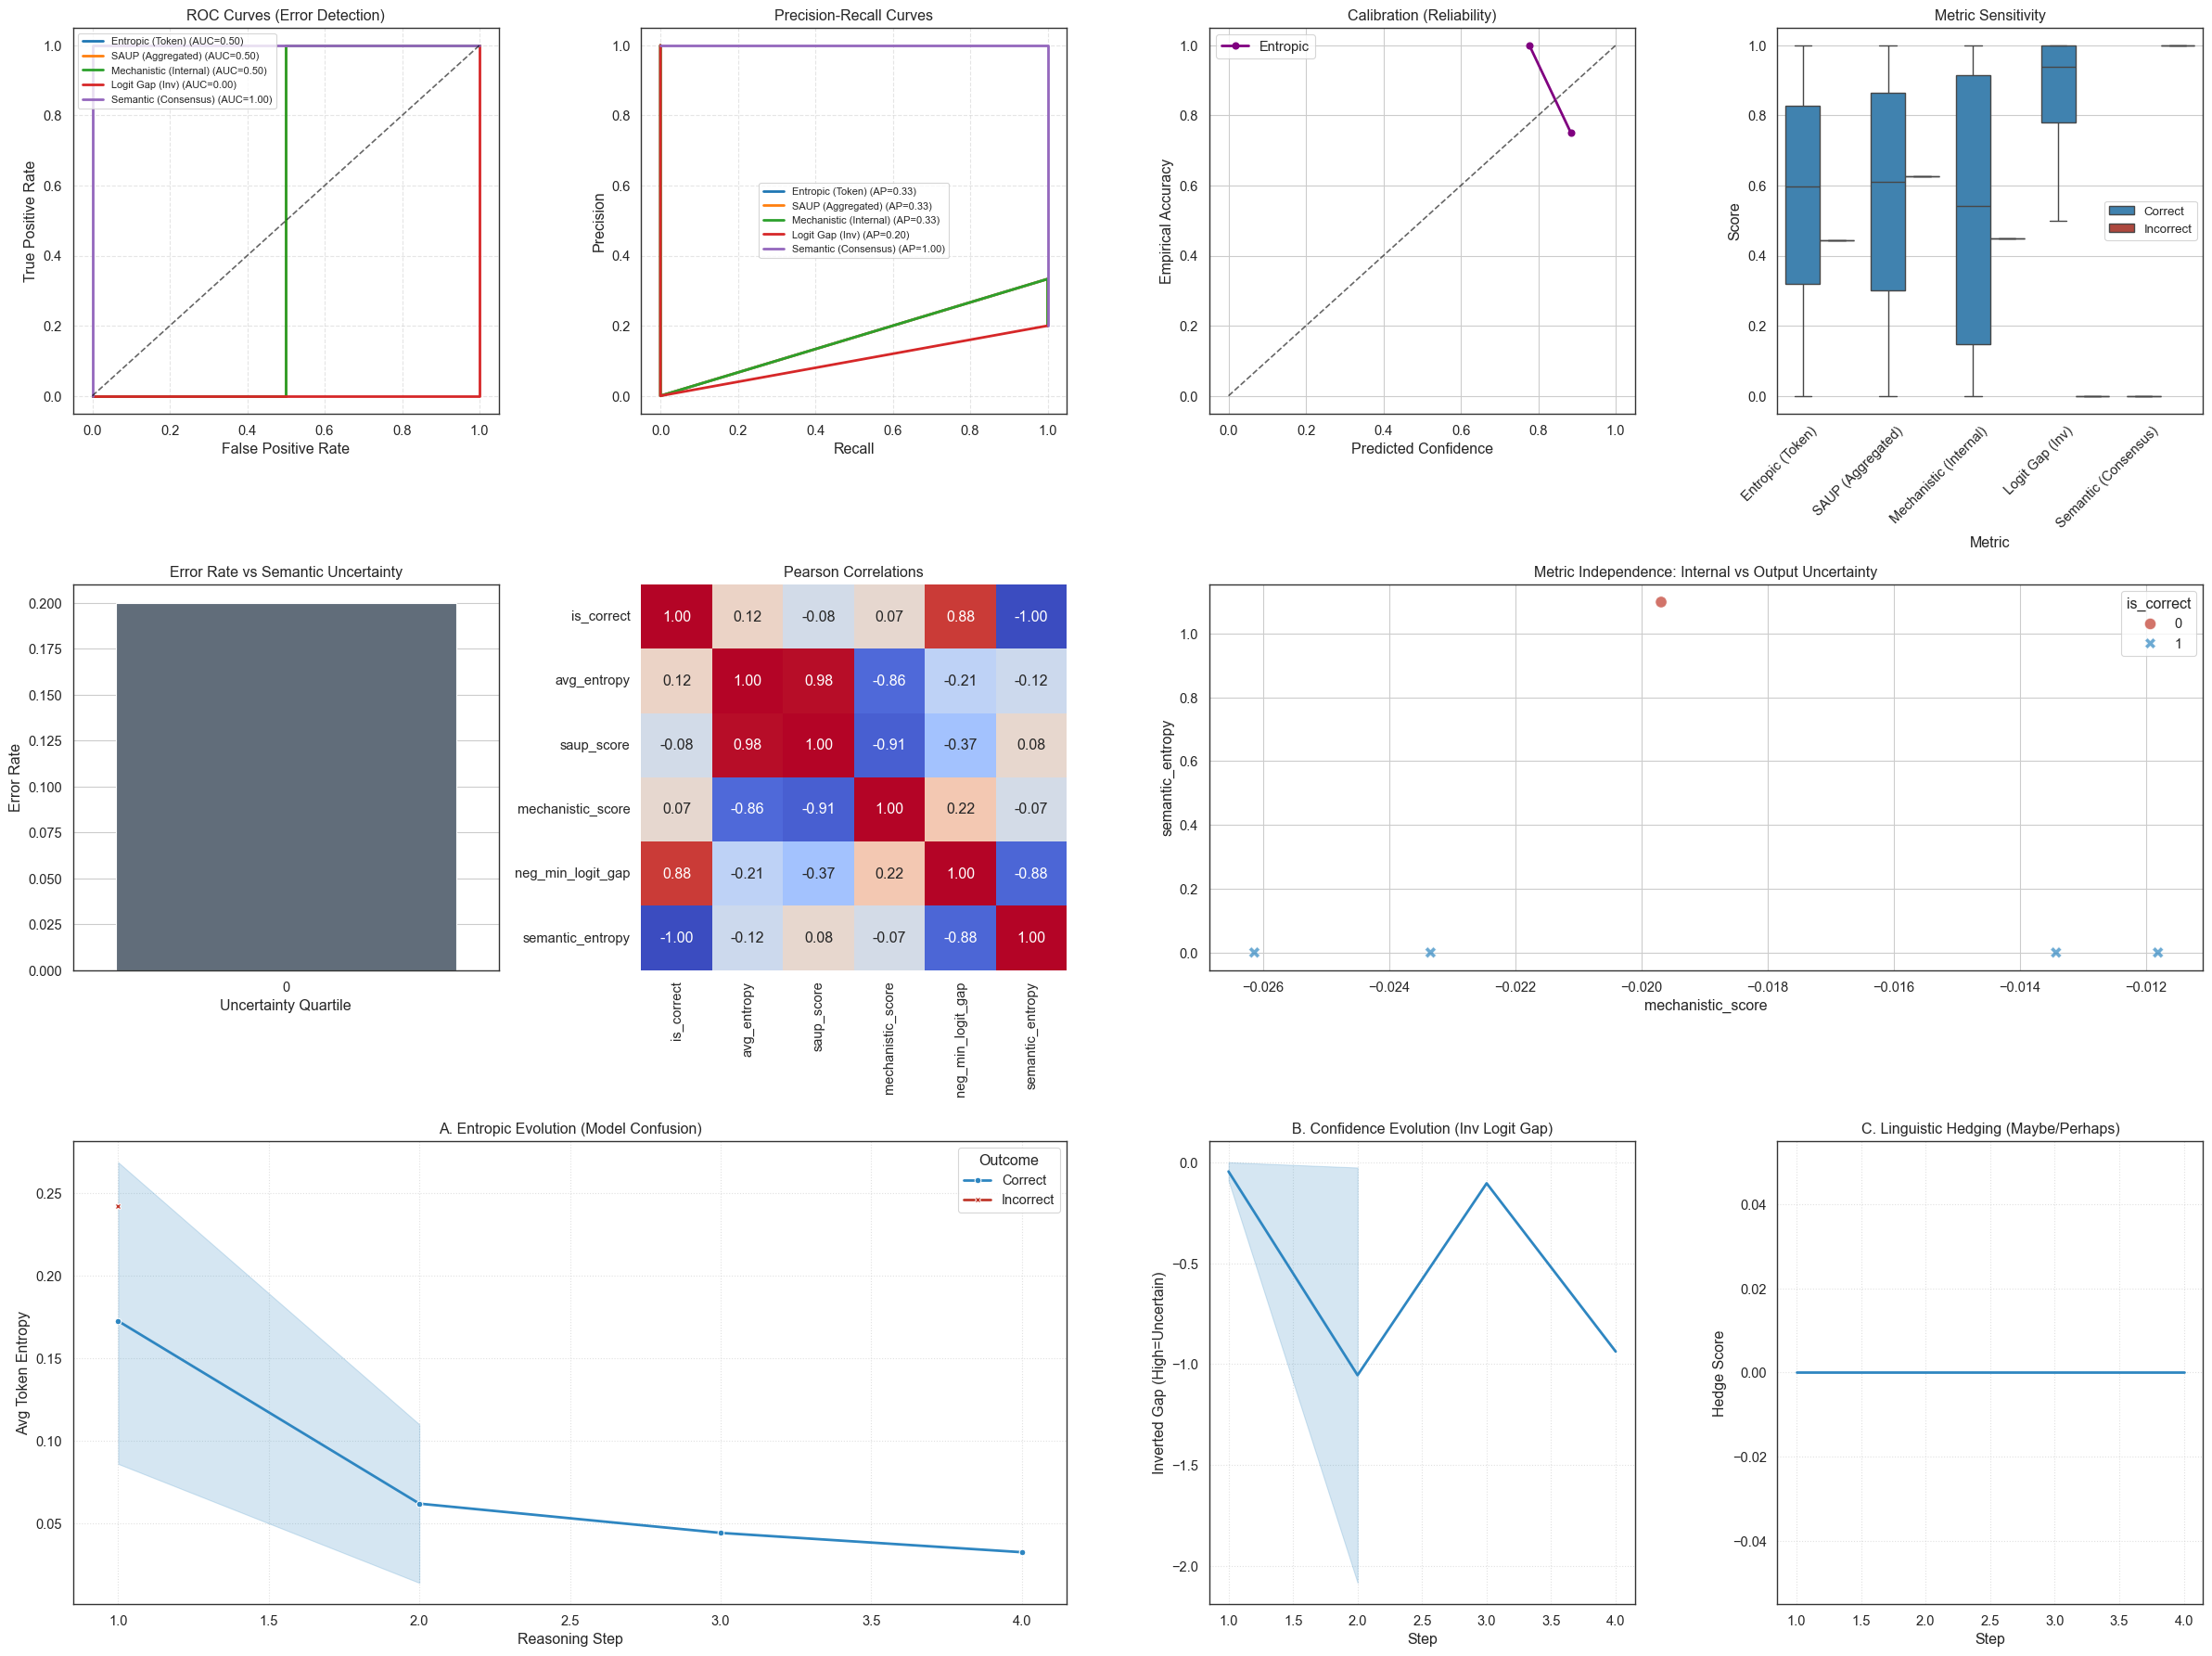

[INFO] Generating Pairwise Matrix...


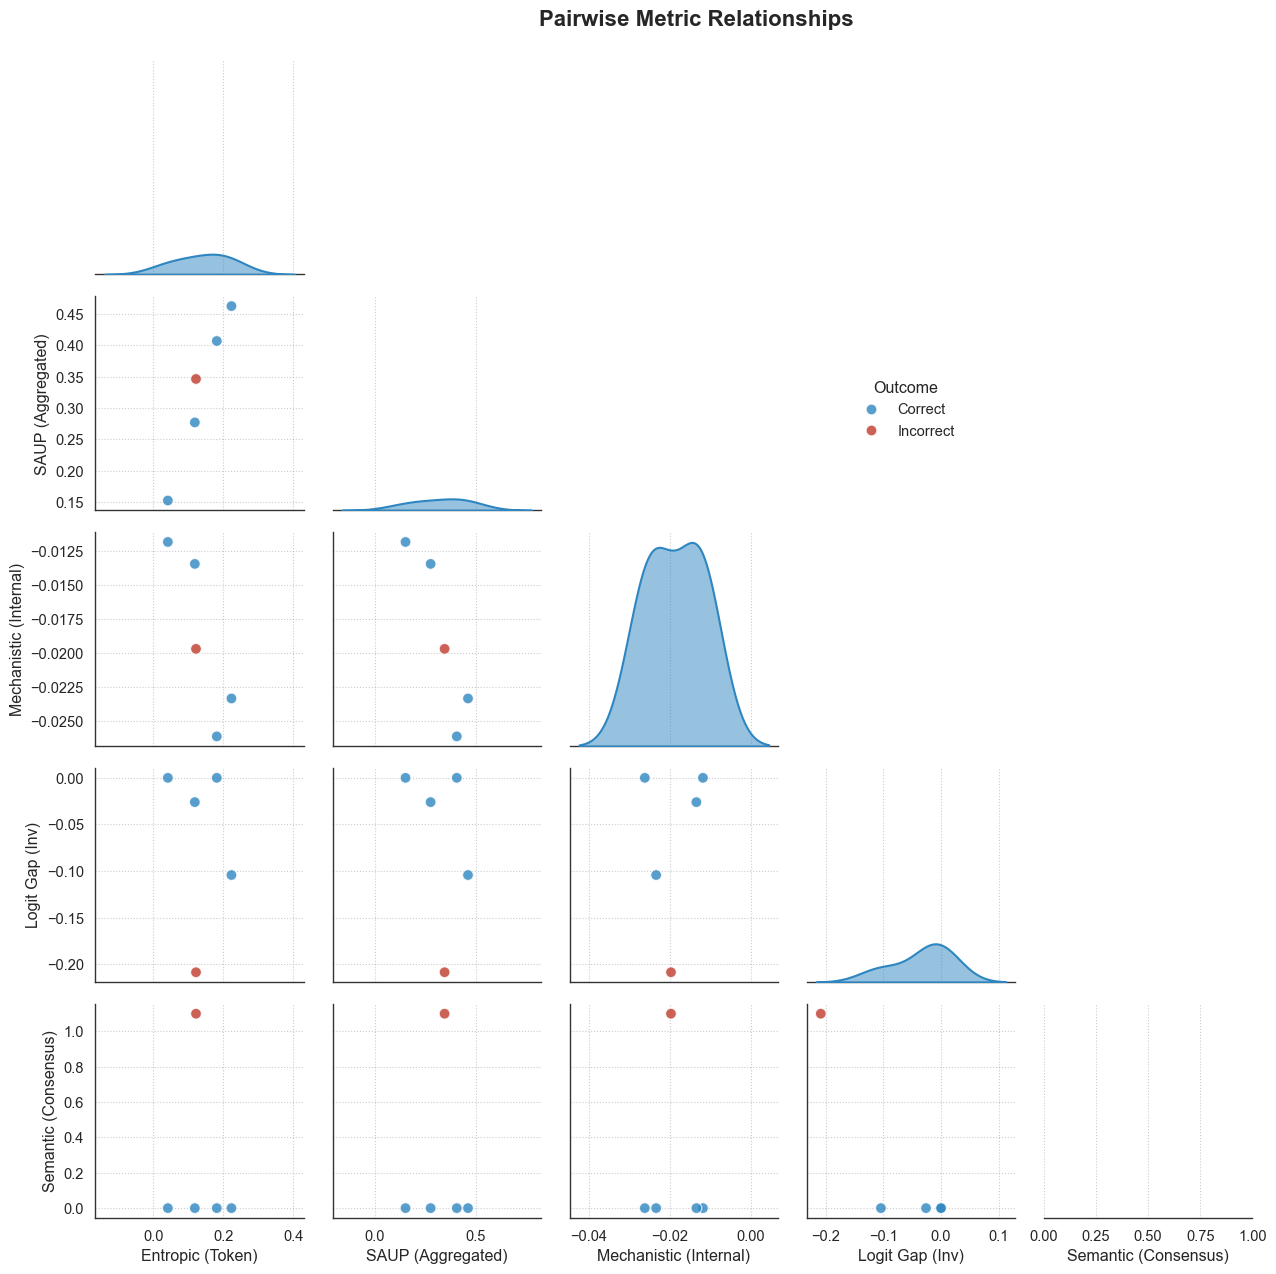

In [ ]:
import os
import re
import json
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pointbiserialr
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid")
plt.rcParams['axes.edgecolor'] = '#333'
plt.rcParams['axes.linewidth'] = 1.0


def load_and_process_data():
    paths = [
        "./output/llama3_large",
        "../output/llama3_large",
        "../../output/llama3_large",
        "draft_repo/output/llama3_large"
    ]
    d = next((p for p in paths if os.path.exists(p)), None)
    if not d:
        return None, None

    try:
        df = pd.read_csv(os.path.join(d, "experiment_summary.csv"))
        with open(os.path.join(d, "full_results.json"), "r") as f:
            full = json.load(f)

        if "min_logit_gap" in df.columns:
            df["neg_min_logit_gap"] = -df["min_logit_gap"]

        return df, full
    except:
        return None, None


UQ = [
    "avg_entropy",
    "saup_score",
    "mechanistic_score",
    "neg_min_logit_gap",
    "semantic_entropy",
    "heuristic_score"
]

LABEL = {
    "avg_entropy": "Entropic",
    "saup_score": "SAUP",
    "mechanistic_score": "Mechanistic",
    "neg_min_logit_gap": "LogitGapInv",
    "semantic_entropy": "Semantic",
    "heuristic_score": "Heuristic"
}


def calculate_step_heuristic(t):
    if not isinstance(t, str):
        return 0.0
    w = ["maybe","perhaps","likely","unclear","might","possible","assuming","seems"]
    c = sum(1 for x in w if x in t.lower())
    return c / (len(t.split()) + 1)


def generate_formal_report(df):
    if df["is_correct"].nunique() < 2:
        return pd.DataFrame(), pd.DataFrame()

    metrics = [m for m in UQ if m in df.columns and df[m].std() > 0]
    err = 1 - df["is_correct"]
    report = []

    for m in metrics:
        auroc = roc_auc_score(err, df[m])
        ap = average_precision_score(err, df[m])
        r, p = pointbiserialr(df["is_correct"], df[m])
        report.append({
            "Metric": LABEL.get(m, m),
            "AUROC": round(auroc, 4),
            "AP": round(ap, 4),
            "r_pb": round(r, 4),
            "p": float(f"{p:.4e}")
        })

    R = pd.DataFrame(report).sort_values("AUROC", ascending=False)

    syn = []
    if len(metrics) > 1:
        C = df[metrics].corr().abs()
        for i in range(len(metrics)):
            for j in range(i+1, len(metrics)):
                m1, m2 = metrics[i], metrics[j]
                r = C.loc[m1, m2]
                syn.append({
                    "Pair": f"{LABEL[m1]} / {LABEL[m2]}",
                    "Corr": round(r, 4),
                    "Type": "Redundant" if r > 0.8 else ("Complementary" if r < 0.4 else "Correlated")
                })

    S = pd.DataFrame(syn).sort_values("Corr", ascending=False)
    return R, S


def plot_academic_dashboard(df, full):
    metrics = [m for m in UQ if m in df.columns and df[m].std() > 0]
    err = 1 - df["is_correct"]
    has_var = df["is_correct"].nunique() > 1

    fig = plt.figure(figsize=(22, 17))
    gs = fig.add_gridspec(3, 4, height_ratios=[1, 1, 1.2])

    # ROC
    ax = fig.add_subplot(gs[0, 0])
    if has_var:
        for m in metrics:
            fpr, tpr, _ = roc_curve(err, df[m])
            auc = roc_auc_score(err, df[m])
            ax.plot(fpr, tpr, label=f"{LABEL[m]} ({auc:.2f})", lw=2)
        ax.plot([0,1],[0,1],'k--',alpha=0.6)
        ax.set_title("ROC")
        ax.legend(fontsize=8)

    # PR
    ax = fig.add_subplot(gs[0, 1])
    if has_var:
        for m in metrics:
            p, r, _ = precision_recall_curve(err, df[m])
            ap = average_precision_score(err, df[m])
            ax.plot(r, p, lw=2, label=f"{LABEL[m]} ({ap:.2f})")
        ax.set_title("PR")
        ax.legend(fontsize=8)

    # Calibration (use entropic only)
    ax = fig.add_subplot(gs[0, 2])
    if has_var and "avg_entropy" in df.columns:
        pt, pp = calibration_curve(df["is_correct"], 1 - df["avg_entropy"], n_bins=5)
        ax.plot(pp, pt, "o-", lw=2)
        ax.plot([0,1],[0,1],"k--",alpha=0.6)
        ax.set_title("Calibration")

    # Distributions
    ax = fig.add_subplot(gs[0, 3])
    if metrics:
        sc = MinMaxScaler()
        z = df.copy()
        z[metrics] = sc.fit_transform(df[metrics])
        melt = z.melt(id_vars="is_correct", value_vars=metrics, var_name="Metric", value_name="Score")
        melt["Metric"] = melt["Metric"].map(LABEL)
        melt["Outcome"] = melt["is_correct"].map({1:"Correct",0:"Incorrect"})
        sns.boxplot(data=melt, x="Metric", y="Score", hue="Outcome", ax=ax)
        ax.set_title("Sensitivity")
        ax.legend(fontsize=8)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    # Binned semantic
    ax = fig.add_subplot(gs[1, 0])
    if "semantic_entropy" in df.columns:
        df["bin"] = pd.qcut(df["semantic_entropy"], q=4, duplicates="drop", labels=False)
        e = 1 - df.groupby("bin")["is_correct"].mean()
        sns.barplot(x=e.index, y=e.values, ax=ax)
        ax.set_title("Error vs Semantic")

    # Corr matrix
    ax = fig.add_subplot(gs[1, 1])
    if metrics:
        C = df[["is_correct"] + metrics].corr()
        sns.heatmap(C, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
        ax.set_title("Correlations")

    # Mechanistic vs Semantic
    ax = fig.add_subplot(gs[1, 2:])
    if "mechanistic_score" in df.columns and "semantic_entropy" in df.columns:
        sns.scatterplot(
            data=df,
            x="mechanistic_score",
            y="semantic_entropy",
            hue="is_correct",
            palette={1:"#2E86C1",0:"#C0392B"},
            s=80,
            ax=ax
        )
        ax.set_title("Mechanistic vs Semantic")

    # Stepwise analysis
    steps = []
    for r in full:
        v = r.get("stage_vectors", [])
        for i, s in enumerate(v):
            steps.append({
                "qid": r["question_id"],
                "step": i+1,
                "out": "Correct" if r["is_correct"] else "Incorrect",
                "ent": s.get("avg_entropy",0),
                "gap": s.get("min_logit_gap",0),
                "heur": calculate_step_heuristic(s.get("text_segment",""))
            })

    S = pd.DataFrame(steps)
    if not S.empty:
        # Entropy evolution
        ax = fig.add_subplot(gs[2, 0:2])
        sns.lineplot(data=S, x="step", y="ent", hue="out",
                     palette={"Correct":"#2E86C1","Incorrect":"#C0392B"},
                     lw=2, ax=ax)
        ax.set_title("Entropy by Step")

        # Gap evolution
        ax = fig.add_subplot(gs[2, 2])
        S["inv_gap"] = -S["gap"]
        sns.lineplot(data=S, x="step", y="inv_gap", hue="out",
                     palette={"Correct":"#2E86C1","Incorrect":"#C0392B"},
                     lw=2, ax=ax, legend=False)
        ax.set_title("LogitGapInv")

        # Heuristic evolution
        ax = fig.add_subplot(gs[2, 3])
        sns.lineplot(data=S, x="step", y="heur", hue="out",
                     palette={"Correct":"#2E86C1","Incorrect":"#C0392B"},
                     lw=2, ax=ax, legend=False)
        ax.set_title("Hedging by Step")

    plt.tight_layout()
    plt.show()


def plot_sharp_pairwise(df):
    metrics = [m for m in UQ if m in df.columns and df[m].std() > 0]
    if len(metrics) < 2:
        return

    p = df[metrics + ["is_correct"]].copy()
    p = p.rename(columns=LABEL)
    p["Outcome"] = p["is_correct"].map({1:"Correct",0:"Incorrect"})
    p = p.drop(columns=["is_correct"])

    g = sns.PairGrid(p, hue="Outcome",
                     palette={"Correct":"#2E86C1","Incorrect":"#C0392B"},
                     corner=True, height=2.4)
    g.map_diag(sns.kdeplot, fill=True, alpha=0.5)
    g.map_lower(sns.scatterplot, s=55, edgecolor="white", lw=0.5, alpha=0.7)

    g.add_legend()
    plt.show()


if __name__ == "__main__":
    df, full = load_and_process_data()
    if df is None:
        exit()

    R, S = generate_formal_report(df)
    if not R.empty:
        print(R.to_string(index=False))
        print()
        print(S.head(10).to_string(index=False))

    plot_academic_dashboard(df, full)
    plot_sharp_pairwise(df)
